# PI Few-Shot Prototypical Training

Train a prototypical multi-antenna SHARP encoder on the source PI domains, then compare K-shot target-domain prototype inference against the saved softmax baseline checkpoint.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DOPPLER_DIR = PROJECT_ROOT / "data" / "doppler_traces_pi"
SOFTMAX_CHECKPOINT_PATH = PROJECT_ROOT / "experiments" / "pi_classification" / "pi_all_persons_123_train_4_test_sharp_model_20260525_165437" / "model.pt"

RUN_GROUP = "few_shot_proto_evaluation"
RUN_NAME = "proto_pooled_head_vs_softmax_baseline"


## Imports And Experiment Constants

In [2]:
import gc
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display
from torch.cuda import is_available
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from wifi_doppler.data.dataset import DopplerWindowDataset
from wifi_doppler.evaluation.fewshot import evaluate_kshot, window_true_labels_from_recordings
from wifi_doppler.experiments.artifacts import create_run_dir, plot_step_curves, save_checkpoint, save_figure, save_json
from wifi_doppler.models.sharp import MultiAntennaEncoder, MultiAntennaModel, SingleAntennaModel, build_sharp_single_antenna_encoder
from wifi_doppler.training.prototypical import load_cross_dataset_episode, load_episode, prototypical_loss, sample_cross_dataset_episode_indices, sample_episode_indices

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if is_available() else "cpu"
softmax_checkpoint = torch.load(SOFTMAX_CHECKPOINT_PATH, map_location=device, weights_only=False)
softmax_config = softmax_checkpoint["config"]

PERSONS = softmax_checkpoint["labels"]
TRAIN_SCENARIOS = softmax_config.get("train_scenarios", ["PI-1a", "PI-2a", "PI-3a"])
TARGET_SCENARIOS = softmax_config.get("test_scenarios", ["PI-4a"])
WINDOW_SIZE = softmax_config.get("window_size", 340)
WINDOW_STRIDE = softmax_config.get("window_stride", 30)
SOFTMAX_FUSION = softmax_config.get("fusion", "mean")

SOURCE_TRAIN_SPLIT = (0.0, 0.6)
SOURCE_VAL_SPLIT = (0.6, 0.8)
TARGET_ENROLLMENT_SPLIT = (0.0, 0.6)
TARGET_QUERY_SPLIT = (0.6, 0.8)

TOTAL_PROTO_STEPS = 3000
EVAL_EVERY_STEPS = 100
PROTO_TEST_EPISODES_PER_EVAL = 20
LIVE_PLOT_EVERY_STEPS = 1
PROTO_N_WAY = len(PERSONS)
PROTO_K_SHOT = 5
PROTO_Q_QUERY = 16
PROTO_LR = 1e-4
PROTO_EMBEDDING_DIM = 128
PROTO_ENCODER_TYPE = "pooled"
PROTO_POOL_SIZE = (10, 10)
PROTO_HIDDEN_DIM = None
PROTO_HEAD_DROPOUT = 0.0
PROTO_TEMPERATURE = 0.1
EARLY_STOP_METRIC = "proto_source_val_acc"
EARLY_STOP_PATIENCE_EVALS = 8
EARLY_STOP_MIN_DELTA = 0.0
EMBEDDING_FUSION = "mean"
METRIC = "cosine"

K_VALUES = [1, 3, 5, 10, 25, 50, 100]
N_TRIALS = 20
EVAL_BATCH_SIZE = 128

print("Softmax checkpoint:", SOFTMAX_CHECKPOINT_PATH)
print("Train scenarios:", TRAIN_SCENARIOS)
print("Target scenarios:", TARGET_SCENARIOS)
print("Labels:", PERSONS)
print("Device:", device)


Softmax checkpoint: C:\Users\gianm\Development\wifi-doppler-har\experiments\pi_classification\pi_all_persons_123_train_4_test_sharp_model_20260525_165437\model.pt
Train scenarios: ['PI-1a', 'PI-2a', 'PI-3a']
Target scenarios: ['PI-4a']
Labels: ['p03', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13']
Device: cuda


## Build Source And Target Datasets

The prototypical model is trained only on the source domains. The target domain is split into enrollment and query windows for post-training K-shot evaluation.

In [3]:
proto_train_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TRAIN_SCENARIOS,
    split=SOURCE_TRAIN_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)

source_val_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TRAIN_SCENARIOS,
    split=SOURCE_VAL_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)

target_enrollment_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TARGET_SCENARIOS,
    split=TARGET_ENROLLMENT_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)

target_query_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=TARGET_SCENARIOS,
    split=TARGET_QUERY_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)

proto_train_labels = window_true_labels_from_recordings(proto_train_dataset)
source_val_labels = window_true_labels_from_recordings(source_val_dataset)
target_enrollment_labels = window_true_labels_from_recordings(target_enrollment_dataset)
target_query_labels = window_true_labels_from_recordings(target_query_dataset)

print("Source train windows:", len(proto_train_dataset))
print("Source validation windows:", len(source_val_dataset))
print("Target enrollment windows:", len(target_enrollment_dataset))
print("Target query windows:", len(target_query_dataset))


Source train windows: 26801
Source validation windows: 8685
Target enrollment windows: 8738
Target query windows: 2830


## Train Prototypical Multi-Antenna Encoder

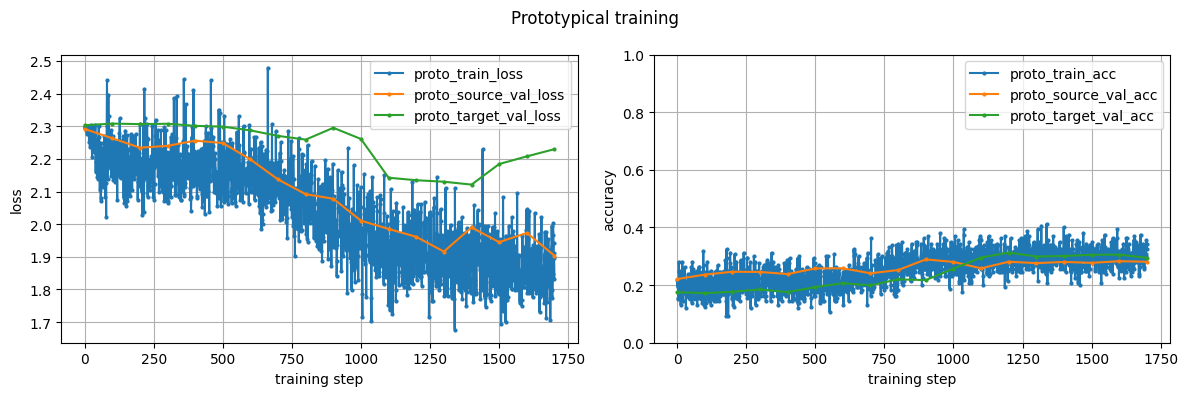

step 1700/3000: proto_train_loss=1.8309 proto_train_acc=0.3438 proto_source_val_loss=1.9038 proto_source_val_acc=0.2809 proto_target_val_loss=2.2298 proto_target_val_acc=0.2947
No proto_source_val_acc improvement for 8/8 evals
Early stopping at step 1700. Best proto_source_val_acc=0.2891 at step 900.
Saved trained proto model before few-shot evaluation: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_pooled_head_vs_softmax_baseline_20260528_220334\proto_model_after_training.pt
Loaded best proto model from step 900 for few-shot evaluation.
Cleared cached recording arrays before few-shot evaluation.


In [4]:
def build_proto_encoder(device: str | torch.device):
    model = MultiAntennaEncoder(
        build_sharp_single_antenna_encoder(
            encoder_type=PROTO_ENCODER_TYPE,
            embedding_dim=PROTO_EMBEDDING_DIM,
            hidden_dim=PROTO_HIDDEN_DIM,
            pool_size=PROTO_POOL_SIZE,
            dropout=PROTO_HEAD_DROPOUT,
            normalize=True,
        )
    ).to(device)
    with torch.no_grad():
        dummy = target_enrollment_dataset[0][0].unsqueeze(0).to(device)
        _ = model.forward_embedding(dummy, fusion=EMBEDDING_FUSION)
    return model


def build_legacy_softmax_model(num_classes: int, device: str | torch.device):
    model = MultiAntennaModel(SingleAntennaModel(num_classes=num_classes)).to(device)
    with torch.no_grad():
        dummy = target_enrollment_dataset[0][0].unsqueeze(0).to(device)
        _ = model.forward_antennas(dummy)
    return model


def evaluate_same_dataset_proto_episodes(model, dataset, labels, rng):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for _ in range(PROTO_TEST_EPISODES_PER_EVAL):
            support_indices, query_indices = sample_episode_indices(
                labels,
                n_way=PROTO_N_WAY,
                k_shot=PROTO_K_SHOT,
                q_query=PROTO_Q_QUERY,
                rng=rng,
            )
            episode = load_episode(dataset, support_indices, query_indices)
            loss, acc = prototypical_loss(
                model,
                episode,
                device=device,
                embedding_fusion=EMBEDDING_FUSION,
                metric=METRIC,
                temperature=PROTO_TEMPERATURE,
            )
            total_loss += loss.item()
            total_acc += acc

    return {
        "loss": total_loss / PROTO_TEST_EPISODES_PER_EVAL,
        "acc": total_acc / PROTO_TEST_EPISODES_PER_EVAL,
    }


def evaluate_cross_dataset_proto_episodes(model, support_dataset, support_labels, query_dataset, query_labels, rng):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for _ in range(PROTO_TEST_EPISODES_PER_EVAL):
            support_indices, query_indices = sample_cross_dataset_episode_indices(
                support_labels,
                query_labels,
                n_way=PROTO_N_WAY,
                k_shot=PROTO_K_SHOT,
                q_query=PROTO_Q_QUERY,
                rng=rng,
            )
            episode = load_cross_dataset_episode(support_dataset, support_indices, query_dataset, query_indices)
            loss, acc = prototypical_loss(
                model,
                episode,
                device=device,
                embedding_fusion=EMBEDDING_FUSION,
                metric=METRIC,
                temperature=PROTO_TEMPERATURE,
            )
            total_loss += loss.item()
            total_acc += acc

    return {
        "loss": total_loss / PROTO_TEST_EPISODES_PER_EVAL,
        "acc": total_acc / PROTO_TEST_EPISODES_PER_EVAL,
    }


def show_live_proto_curves(history):
    fig, _ = plot_step_curves(
        history,
        loss_keys=["proto_train_loss", "proto_source_val_loss", "proto_target_val_loss"],
        acc_keys=["proto_train_acc", "proto_source_val_acc", "proto_target_val_acc"],
        title="Prototypical training",
    )
    clear_output(wait=True)
    display(fig)
    plt.close(fig)


proto_config = {
    "baseline_softmax_checkpoint": SOFTMAX_CHECKPOINT_PATH,
    "doppler_dir": DOPPLER_DIR,
    "train_scenarios": TRAIN_SCENARIOS,
    "target_scenarios": TARGET_SCENARIOS,
    "source_train_split": SOURCE_TRAIN_SPLIT,
    "source_val_split": SOURCE_VAL_SPLIT,
    "target_enrollment_split": TARGET_ENROLLMENT_SPLIT,
    "target_query_split": TARGET_QUERY_SPLIT,
    "window_size": WINDOW_SIZE,
    "window_stride": WINDOW_STRIDE,
    "total_proto_steps": TOTAL_PROTO_STEPS,
    "eval_every_steps": EVAL_EVERY_STEPS,
    "proto_val_episodes_per_eval": PROTO_TEST_EPISODES_PER_EVAL,
    "live_plot_every_steps": LIVE_PLOT_EVERY_STEPS,
    "proto_n_way": PROTO_N_WAY,
    "proto_k_shot": PROTO_K_SHOT,
    "proto_q_query": PROTO_Q_QUERY,
    "proto_lr": PROTO_LR,
    "proto_encoder_type": PROTO_ENCODER_TYPE,
    "proto_embedding_dim": PROTO_EMBEDDING_DIM,
    "proto_pool_size": PROTO_POOL_SIZE,
    "proto_hidden_dim": PROTO_HIDDEN_DIM,
    "proto_head_dropout": PROTO_HEAD_DROPOUT,
    "proto_temperature": PROTO_TEMPERATURE,
    "early_stop_metric": EARLY_STOP_METRIC,
    "early_stop_patience_evals": EARLY_STOP_PATIENCE_EVALS,
    "early_stop_min_delta": EARLY_STOP_MIN_DELTA,
    "embedding_fusion": EMBEDDING_FUSION,
    "metric": METRIC,
    "k_values": K_VALUES,
    "n_trials": N_TRIALS,
    "seed": SEED,
}

run_dir = create_run_dir(PROJECT_ROOT, RUN_GROUP, RUN_NAME)
save_json(run_dir / "proto_config.json", proto_config)
print("Run directory:", run_dir)


def latest_proto_metrics(history):
    return {
        "step": history["step"][-1],
        "latest_proto_train_loss": history["proto_train_loss"][-1],
        "latest_proto_train_acc": history["proto_train_acc"][-1],
        "latest_proto_source_val_loss": history["proto_source_val_loss"][-1],
        "latest_proto_source_val_acc": history["proto_source_val_acc"][-1],
        "latest_proto_target_val_loss": history["proto_target_val_loss"][-1],
        "latest_proto_target_val_acc": history["proto_target_val_acc"][-1],
    }


def is_better_metric(value, best_value):
    return np.isfinite(value) and value > best_value + EARLY_STOP_MIN_DELTA


proto_model = build_proto_encoder(device)
optimizer = torch.optim.Adam(proto_model.parameters(), lr=PROTO_LR)
episode_rng = np.random.default_rng(SEED)
source_val_episode_rng = np.random.default_rng(SEED + 1)
target_val_episode_rng = np.random.default_rng(SEED + 2)

proto_history = {
    "step": [],
    "proto_train_loss": [],
    "proto_train_acc": [],
    "proto_source_val_loss": [],
    "proto_source_val_acc": [],
    "proto_target_val_loss": [],
    "proto_target_val_acc": [],
}
best_metric_value = -np.inf
best_metric_step = None
best_checkpoint_path = run_dir / "proto_model_best.pt"
evals_without_improvement = 0
stopped_early = False

progress = tqdm(range(1, TOTAL_PROTO_STEPS + 1), desc="proto training steps")
for step in progress:
    proto_model.train()
    support_indices, query_indices = sample_episode_indices(
        proto_train_labels,
        n_way=PROTO_N_WAY,
        k_shot=PROTO_K_SHOT,
        q_query=PROTO_Q_QUERY,
        rng=episode_rng,
    )
    episode = load_episode(proto_train_dataset, support_indices, query_indices)

    optimizer.zero_grad()
    loss, acc = prototypical_loss(
        proto_model,
        episode,
        device=device,
        embedding_fusion=EMBEDDING_FUSION,
        metric=METRIC,
        temperature=PROTO_TEMPERATURE,
    )
    loss.backward()
    optimizer.step()

    source_val_metrics = {"loss": np.nan, "acc": np.nan}
    target_val_metrics = {"loss": np.nan, "acc": np.nan}
    should_eval = step == 1 or step % EVAL_EVERY_STEPS == 0 or step == TOTAL_PROTO_STEPS
    if should_eval:
        source_val_metrics = evaluate_same_dataset_proto_episodes(
            proto_model,
            source_val_dataset,
            source_val_labels,
            source_val_episode_rng,
        )
        target_val_metrics = evaluate_cross_dataset_proto_episodes(
            proto_model,
            target_enrollment_dataset,
            target_enrollment_labels,
            target_query_dataset,
            target_query_labels,
            target_val_episode_rng,
        )

    proto_history["step"].append(step)
    proto_history["proto_train_loss"].append(loss.item())
    proto_history["proto_train_acc"].append(acc)
    proto_history["proto_source_val_loss"].append(source_val_metrics["loss"])
    proto_history["proto_source_val_acc"].append(source_val_metrics["acc"])
    proto_history["proto_target_val_loss"].append(target_val_metrics["loss"])
    proto_history["proto_target_val_acc"].append(target_val_metrics["acc"])

    progress.set_postfix(
        train_loss=f"{loss.item():.4f}",
        train_acc=f"{acc:.4f}",
        source_acc="nan" if np.isnan(source_val_metrics["acc"]) else f"{source_val_metrics['acc']:.4f}",
        target_acc="nan" if np.isnan(target_val_metrics["acc"]) else f"{target_val_metrics['acc']:.4f}",
    )

    if step == 1 or step % LIVE_PLOT_EVERY_STEPS == 0 or step == TOTAL_PROTO_STEPS:
        show_live_proto_curves(proto_history)
        print(
            f"step {step:04d}/{TOTAL_PROTO_STEPS}: "
            f"proto_train_loss={loss.item():.4f} proto_train_acc={acc:.4f} "
            f"proto_source_val_loss={source_val_metrics['loss']:.4f} proto_source_val_acc={source_val_metrics['acc']:.4f} "
            f"proto_target_val_loss={target_val_metrics['loss']:.4f} proto_target_val_acc={target_val_metrics['acc']:.4f}"
        )

    if should_eval:
        save_checkpoint(
            proto_model,
            run_dir,
            labels=PERSONS,
            config=proto_config,
            metrics=latest_proto_metrics(proto_history),
            history=proto_history,
            name="proto_model_latest.pt",
        )

        current_metric_value = proto_history[EARLY_STOP_METRIC][-1]
        if is_better_metric(current_metric_value, best_metric_value):
            best_metric_value = current_metric_value
            best_metric_step = step
            evals_without_improvement = 0
            save_checkpoint(
                proto_model,
                run_dir,
                labels=PERSONS,
                config=proto_config,
                metrics={
                    **latest_proto_metrics(proto_history),
                    "best_metric": EARLY_STOP_METRIC,
                    "best_metric_value": best_metric_value,
                    "best_metric_step": best_metric_step,
                },
                history=proto_history,
                name="proto_model_best.pt",
            )
            print(f"New best {EARLY_STOP_METRIC}: {best_metric_value:.4f} at step {best_metric_step}")
        else:
            evals_without_improvement += 1
            print(
                f"No {EARLY_STOP_METRIC} improvement for "
                f"{evals_without_improvement}/{EARLY_STOP_PATIENCE_EVALS} evals"
            )

        if evals_without_improvement >= EARLY_STOP_PATIENCE_EVALS:
            stopped_early = True
            print(
                f"Early stopping at step {step}. "
                f"Best {EARLY_STOP_METRIC}={best_metric_value:.4f} at step {best_metric_step}."
            )
            break

training_checkpoint_path = save_checkpoint(
    proto_model,
    run_dir,
    labels=PERSONS,
    config=proto_config,
    metrics={
        **latest_proto_metrics(proto_history),
        "best_metric": EARLY_STOP_METRIC,
        "best_metric_value": best_metric_value,
        "best_metric_step": best_metric_step,
        "stopped_early": stopped_early,
    },
    history=proto_history,
    name="proto_model_after_training.pt",
)
save_json(
    run_dir / "proto_training_history.json",
    {
        "history": proto_history,
        "config": proto_config,
        "selection": {
            "best_metric": EARLY_STOP_METRIC,
            "best_metric_value": best_metric_value,
            "best_metric_step": best_metric_step,
            "stopped_early": stopped_early,
        },
    },
)
print("Saved trained proto model before few-shot evaluation:", training_checkpoint_path)

best_checkpoint = torch.load(best_checkpoint_path, map_location=device, weights_only=False)
proto_model.load_state_dict(best_checkpoint["model_state_dict"])
proto_model.eval()
print(f"Loaded best proto model from step {best_metric_step} for few-shot evaluation.")

for dataset in (proto_train_dataset, source_val_dataset, target_enrollment_dataset, target_query_dataset):
    dataset.clear_cache()
gc.collect()
if is_available():
    torch.cuda.empty_cache()
print("Cleared cached recording arrays before few-shot evaluation.")


## Load Softmax Baseline

In [5]:
softmax_model = build_legacy_softmax_model(len(PERSONS), device)
softmax_model.load_state_dict(softmax_checkpoint["model_state_dict"])
softmax_model.eval()

print("Loaded softmax baseline.")


Loaded softmax baseline.


## Zero-Shot Softmax Accuracy

In [6]:
def evaluate_softmax_accuracy(model, dataset, device, fusion, batch_size=128):
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x, fusion=fusion)
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)
    return correct / total


zero_shot_softmax_acc = evaluate_softmax_accuracy(
    softmax_model,
    target_query_dataset,
    device,
    SOFTMAX_FUSION,
    batch_size=EVAL_BATCH_SIZE,
)
print(f"Zero-shot softmax accuracy on target query split: {zero_shot_softmax_acc:.4f}")


Zero-shot softmax accuracy on target query split: 0.3159


## K-Shot Prototype Inference Comparison

Both encoders use the same target-domain enrollment/query splits and the same prototype evaluator. This isolates the effect of the training objective: softmax classification vs. episodic prototypical training.

In [7]:
softmax_fewshot_results = evaluate_kshot(
    softmax_model,
    target_enrollment_dataset,
    target_query_dataset,
    K_VALUES,
    device=device,
    n_trials=N_TRIALS,
    seed=SEED,
    batch_size=EVAL_BATCH_SIZE,
    embedding_fusion=EMBEDDING_FUSION,
    metric=METRIC,
)

proto_fewshot_results = evaluate_kshot(
    proto_model,
    target_enrollment_dataset,
    target_query_dataset,
    K_VALUES,
    device=device,
    n_trials=N_TRIALS,
    seed=SEED,
    batch_size=EVAL_BATCH_SIZE,
    embedding_fusion=EMBEDDING_FUSION,
    metric=METRIC,
)

print("K-shot target-domain query accuracy")
for k in K_VALUES:
    softmax_result = softmax_fewshot_results[k]
    proto_result = proto_fewshot_results[k]
    print(
        f"K={k:3d} | "
        f"softmax={softmax_result['mean']:.4f} +/- {softmax_result['std']:.4f} | "
        f"proto={proto_result['mean']:.4f} +/- {proto_result['std']:.4f}"
    )


K-shot target-domain query accuracy
K=  1 | softmax=0.2046 +/- 0.0328 | proto=0.1952 +/- 0.0219
K=  3 | softmax=0.2517 +/- 0.0210 | proto=0.2119 +/- 0.0295
K=  5 | softmax=0.2765 +/- 0.0228 | proto=0.2179 +/- 0.0224
K= 10 | softmax=0.3044 +/- 0.0144 | proto=0.2266 +/- 0.0129
K= 25 | softmax=0.3248 +/- 0.0184 | proto=0.2306 +/- 0.0139
K= 50 | softmax=0.3269 +/- 0.0125 | proto=0.2300 +/- 0.0102
K=100 | softmax=0.3416 +/- 0.0091 | proto=0.2324 +/- 0.0068


## Plot And Save Artifacts

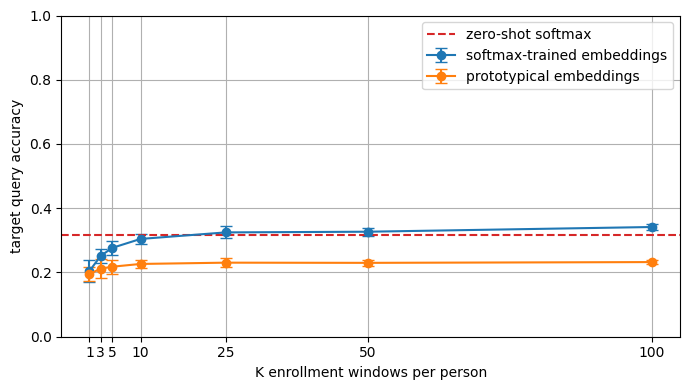

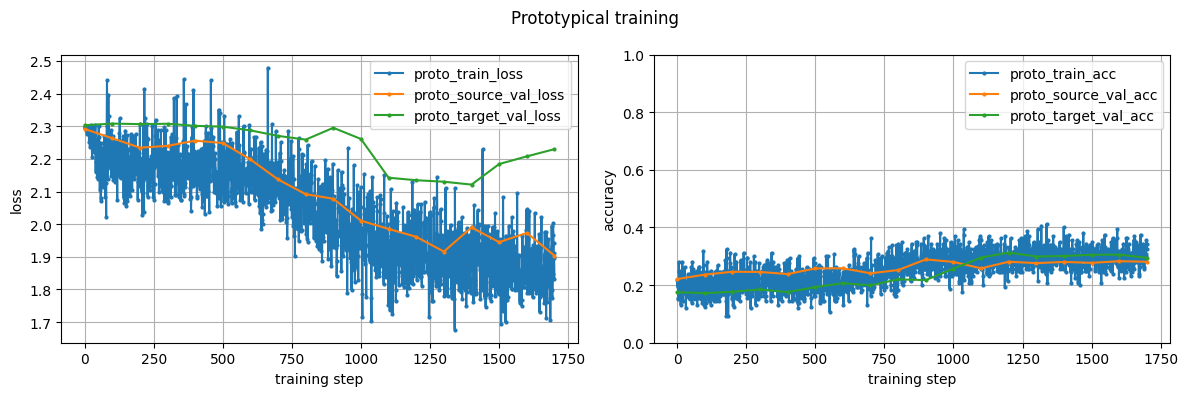

Run directory: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_pooled_head_vs_softmax_baseline_20260528_220334
Results: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_pooled_head_vs_softmax_baseline_20260528_220334\pi_few_shot_proto_vs_softmax_results.json
Proto model: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_pooled_head_vs_softmax_baseline_20260528_220334\proto_model.pt
Comparison plot: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_pooled_head_vs_softmax_baseline_20260528_220334\pi_few_shot_proto_vs_softmax_accuracy.png
Training curves: C:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_pooled_head_vs_softmax_baseline_20260528_220334\proto_training_curves.png


In [8]:
def result_series(results, k_values):
    means = [results[k]["mean"] for k in k_values]
    stds = [results[k]["std"] for k in k_values]
    return means, stds


softmax_means, softmax_stds = result_series(softmax_fewshot_results, K_VALUES)
proto_means, proto_stds = result_series(proto_fewshot_results, K_VALUES)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(K_VALUES, softmax_means, yerr=softmax_stds, marker="o", capsize=4, label="softmax-trained embeddings")
ax.errorbar(K_VALUES, proto_means, yerr=proto_stds, marker="o", capsize=4, label="prototypical embeddings")
ax.axhline(zero_shot_softmax_acc, color="tab:red", linestyle="--", label="zero-shot softmax")
ax.set_xlabel("K enrollment windows per person")
ax.set_ylabel("target query accuracy")
ax.set_ylim(0, 1)
ax.set_xticks(K_VALUES)
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()

history_fig, _ = plot_step_curves(
    proto_history,
    loss_keys=["proto_train_loss", "proto_source_val_loss", "proto_target_val_loss"],
    acc_keys=["proto_train_acc", "proto_source_val_acc", "proto_target_val_acc"],
    title="Prototypical training",
)
plt.show()

comparison_plot_path = save_figure(fig, run_dir, "pi_few_shot_proto_vs_softmax_accuracy.png")
history_plot_path = save_figure(history_fig, run_dir, "proto_training_curves.png")

results = {
    "zero_shot_softmax_acc": zero_shot_softmax_acc,
    "softmax_fewshot_results": softmax_fewshot_results,
    "proto_fewshot_results": proto_fewshot_results,
    "history": proto_history,
    "config": proto_config,
    "artifacts": {
        "comparison_plot": comparison_plot_path,
        "history_plot": history_plot_path,
    },
}

results_path = save_json(run_dir / "pi_few_shot_proto_vs_softmax_results.json", results)
model_path = save_checkpoint(
    proto_model,
    run_dir,
    labels=PERSONS,
    config=proto_config,
    metrics={
        "final_proto_train_loss": proto_history["proto_train_loss"][-1],
        "final_proto_train_acc": proto_history["proto_train_acc"][-1],
        "final_proto_source_val_loss": proto_history["proto_source_val_loss"][-1],
        "final_proto_source_val_acc": proto_history["proto_source_val_acc"][-1],
        "final_proto_target_val_loss": proto_history["proto_target_val_loss"][-1],
        "final_proto_target_val_acc": proto_history["proto_target_val_acc"][-1],
        "best_proto_kshot_acc": max(result["mean"] for result in proto_fewshot_results.values()),
        "best_softmax_kshot_acc": max(result["mean"] for result in softmax_fewshot_results.values()),
        "zero_shot_softmax_acc": zero_shot_softmax_acc,
    },
    history=proto_history,
    name="proto_model.pt",
)

print("Run directory:", run_dir)
print("Results:", results_path)
print("Proto model:", model_path)
print("Comparison plot:", comparison_plot_path)
print("Training curves:", history_plot_path)
